Saving Gemini_Generated_Image_vx73o8vx73o8vx73.png to Gemini_Generated_Image_vx73o8vx73o8vx73 (1).png
Total Face Detected: 4


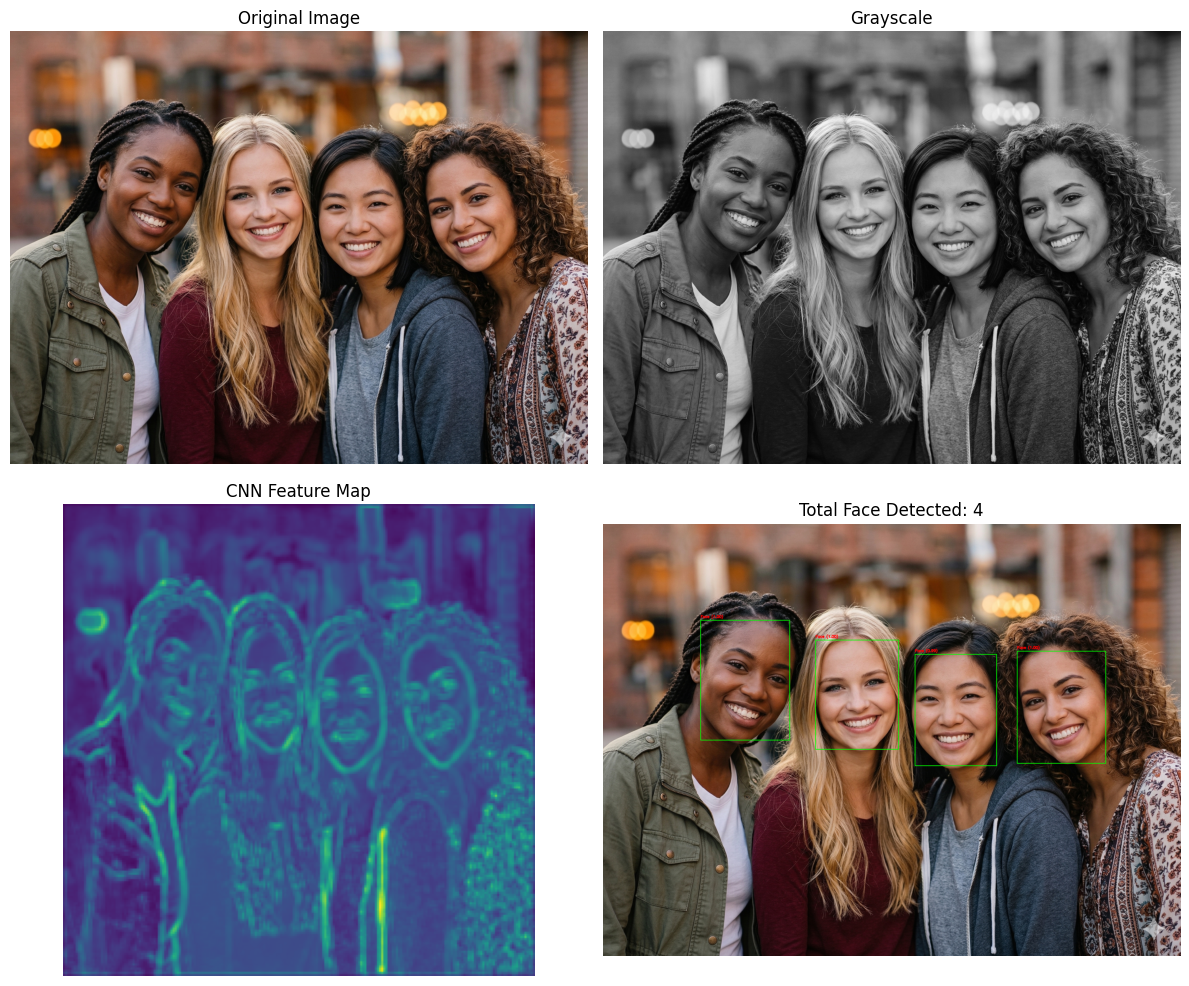

In [3]:
!pip install -q mtcnn

import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

base_model = VGG16(weights='imagenet', include_top=False)
feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer('block1_conv2').output)
img_resized = cv2.resize(original, (224, 224))
img_array = np.expand_dims(img_resized, axis=0)
img_array = preprocess_input(img_array)
feature_map = feature_extractor.predict(img_array, verbose=0)
feature_map_avg = np.mean(feature_map[0], axis=-1)

detector = MTCNN()
faces = detector.detect_faces(original)

confidence_threshold = 0.95
valid_faces = [face for face in faces if face['confidence'] > confidence_threshold]
total_faces = len(valid_faces)

detected_image = original.copy()
for face in valid_faces:
    x, y, w, h = face['box']
    conf = face['confidence']
    cv2.rectangle(detected_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(detected_image, f"Face ({conf:.2f})", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

print(f"Total Face Detected: {total_faces}")

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(feature_map_avg, cmap="viridis")
plt.title("CNN Feature Map")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(detected_image)
plt.title(f"Total Face Detected: {total_faces}")
plt.axis("off")

plt.tight_layout()
plt.show()